# Wigner–Ville Distribution (WVD) in Python

This notebook explores the **Wigner–Ville distribution**, a quadratic time-frequency representation with exceptional resolution. We will cover:

- Mathematical definition and properties (real-valuedness, marginals)
- Why WVD achieves perfect time-frequency resolution for single components
- The analytic signal and aliasing in the WVD
- Cross-terms: the bilinear interference phenomenon
- Cross Wigner–Ville distribution between two signals
- Marginal properties: energy conservation in time and frequency
- Smoothed Pseudo-Wigner–Ville (SPWVD) for cross-term suppression
- Comparison with STFT spectrogram

**Requirements:** `numpy`, `matplotlib`, `scipy`


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert, stft
from scipy.ndimage import gaussian_filter1d
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 10


## 1. Mathematical Definition

The Wigner–Ville distribution is defined for a continuous signal $x(t)$ as:

$$W_x(t, f) = \int_{-\infty}^{\infty} x\left(t + \frac{\tau}{2}\right) x^*\left(t - \frac{\tau}{2}\right) e^{-j 2\pi f \tau} d\tau$$

For a discrete signal $x[n]$, the discrete WVD becomes:

$$W[n, k] = 2 \sum_{m=-M}^{M-1} x[n+m] \, x^*[n-m] \, e^{-j \frac{4\pi}{N} k m}$$

Key properties:
- **Real-valued**: $W(t,f)$ is always real (but can be negative)
- **Energy conservation**: integrates to total signal energy
- **Marginals**: $\int W(t,f) df = |x(t)|^2$ and $\int W(t,f) dt = |X(f)|^2$
- **Quadratic**: if $x = x_1 + x_2$, then $W_x = W_{x_1} + W_{x_2} + 2 \, W_{x_1,x_2}$

The last property creates **cross-terms** (interference) between distinct signal components.


In [21]:
def wigner_ville(x, fs, max_lag=None, lag_window=None, time_sigma=None):
    """Compute the (Pseudo) Wigner-Ville distribution."""
    x = np.asarray(x, dtype=complex)
    N = len(x)
    
    if max_lag is None:
        max_lag = N // 2
    max_lag = min(max_lag, N // 2)
    
    n_lags = 2 * max_lag
    K = np.zeros((N, n_lags), dtype=complex)
    
    # Instantaneous autocorrelation: positive lags (including zero)
    for m in range(max_lag):
        valid = N - 2 * m
        if valid > 0:
            idx = max_lag + m
            K[m : m + valid, idx] = x[2*m : 2*m + valid] * np.conj(x[0 : valid])
    
    # Negative lags
    for m in range(1, max_lag + 1):
        valid = N - 2 * m
        if valid > 0:
            idx = max_lag - m
            K[m : m + valid, idx] = x[0 : valid] * np.conj(x[2*m : 2*m + valid])
    
    # Apply lag window for pseudo-WVD
    if lag_window is not None:
        win = np.zeros(n_lags)
        wlen = min(len(lag_window), n_lags)
        start = (n_lags - wlen) // 2
        win[start : start + wlen] = lag_window[:wlen]
        K *= win[np.newaxis, :]
    
    # FFT along lag axis
    K_shifted = np.fft.ifftshift(K, axes=1)
    W = np.fft.fft(K_shifted, axis=1)
    W = np.real(W)
    W = np.fft.fftshift(W, axes=1)
    
    # Optional time-domain Gaussian smoothing (for SPWVD)
    if time_sigma is not None and time_sigma > 0:
        W = gaussian_filter1d(W, sigma=time_sigma, axis=0, mode='constant')
    
    freqs = np.fft.fftshift(np.fft.fftfreq(n_lags, 1/fs))
    t = np.arange(N) / fs
    return t, freqs, W


## 2. Single-Component Chirp: Perfect Resolution

For a signal with a single time-varying frequency component (like a chirp), the WVD produces a razor-sharp line in the time-frequency plane with no spreading. This is impossible with the STFT, which suffers from the Heisenberg uncertainty trade-off.

The WVD is the only quadratic distribution that satisfies all desirable mathematical properties simultaneously, but this perfection holds only for single-component signals.


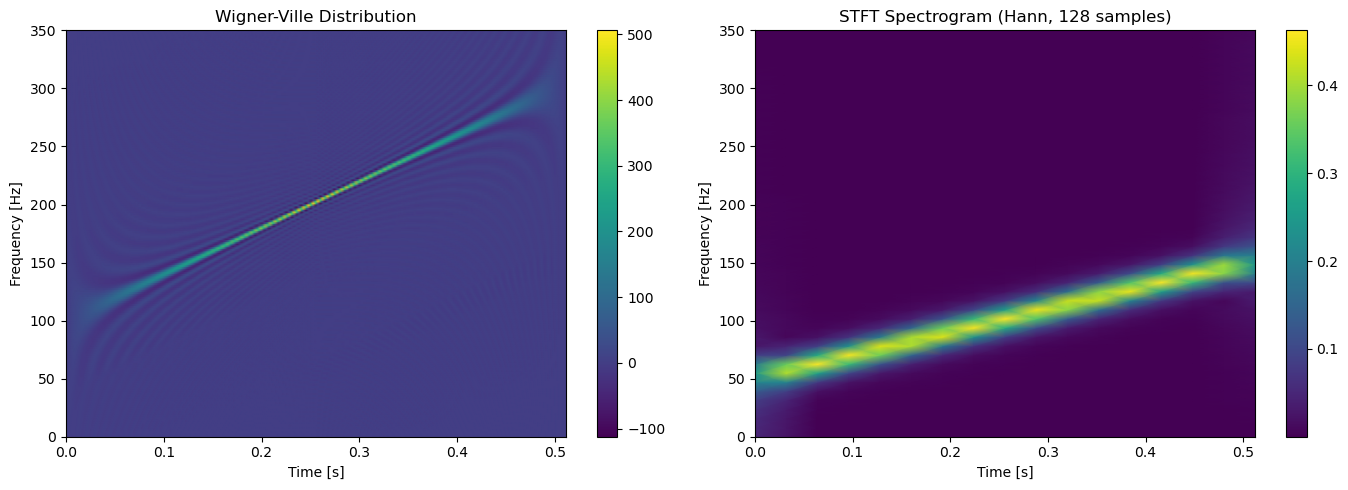

In [22]:
fs = 1000
N = 512
t = np.arange(N) / fs

# Linear chirp: 50 Hz to 250 Hz
f0, f1 = 50, 250
chirp = np.sin(2 * np.pi * (f0 + (f1 - f0) * t / 2) * t)

# Analytic signal (essential for clean WVD)
chirp_a = hilbert(chirp)

# WVD
t_wvd, f_wvd, W = wigner_ville(chirp_a, fs)

# STFT for comparison
f_stft, t_stft, Zxx = stft(chirp, fs=fs, window='hann', nperseg=128, noverlap=96)

# Plot positive frequencies only
pos_mask = f_wvd >= 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im1 = axes[0].pcolormesh(t_wvd, f_wvd[pos_mask], W[:, pos_mask].T,
                          shading='gouraud', cmap='viridis')
axes[0].set_title('Wigner-Ville Distribution')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Frequency [Hz]')
axes[0].set_ylim(0, 350)
fig.colorbar(im1, ax=axes[0])

im2 = axes[1].pcolormesh(t_stft, f_stft, np.abs(Zxx),
                          shading='gouraud', cmap='viridis')
axes[1].set_title('STFT Spectrogram (Hann, 128 samples)')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Frequency [Hz]')
axes[1].set_ylim(0, 350)
fig.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()


## 3. The Analytic Signal

For real signals, the WVD contains interference between positive and negative frequencies. The **analytic signal** (via the Hilbert transform) removes negative frequencies, yielding a one-sided spectrum and eliminating this artifact.

Without the analytic signal, the WVD shows a mirrored, aliased pattern that obscures the true time-frequency content.


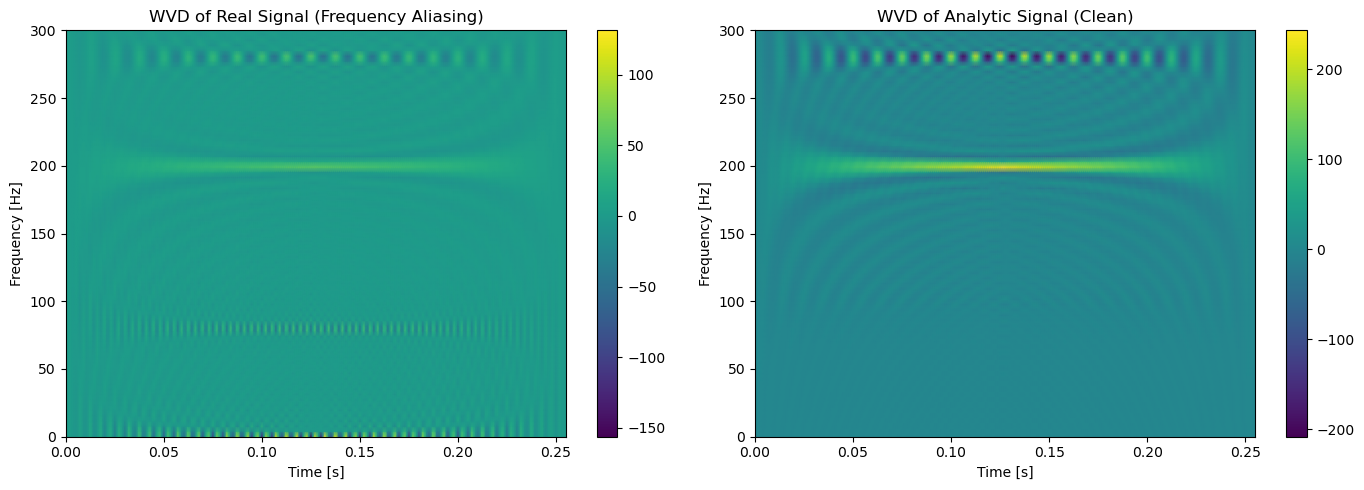

In [23]:
fs = 1000
N = 256
t = np.arange(N) / fs
signal = np.sin(2 * np.pi * 100 * t) + 0.5 * np.sin(2 * np.pi * 180 * t)

# WVD of real signal
t_wvd, f_wvd, W_real = wigner_ville(signal, fs, max_lag=200)
# WVD of analytic signal
t_wvd_a, f_wvd_a, W_analytic = wigner_ville(hilbert(signal), fs, max_lag=200)

pos_mask = f_wvd >= 0
pos_mask_a = f_wvd_a >= 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im1 = axes[0].pcolormesh(t_wvd, f_wvd[pos_mask], W_real[:, pos_mask].T,
                          shading='gouraud', cmap='viridis')
axes[0].set_title('WVD of Real Signal (Frequency Aliasing)')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Frequency [Hz]')
axes[0].set_ylim(0, 300)
fig.colorbar(im1, ax=axes[0])

im2 = axes[1].pcolormesh(t_wvd_a, f_wvd_a[pos_mask_a], W_analytic[:, pos_mask_a].T,
                          shading='gouraud', cmap='viridis')
axes[1].set_title('WVD of Analytic Signal (Clean)')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Frequency [Hz]')
axes[1].set_ylim(0, 300)
fig.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()


## 4. Cross-Terms: The Bilinear Interference

For a multi-component signal $x = x_1 + x_2$, the WVD contains:

$$W_x = W_{x_1} + W_{x_2} + 2 \, W_{x_1,x_2}$$

The **cross-term** $W_{x_1,x_2}$ oscillates in time and appears midway between the true frequencies. For two tones at $f_1$ and $f_2$, the cross-term sits at $(f_1+f_2)/2$ with oscillation frequency $|f_1-f_2|$.

These oscillating interferences are the price paid for the WVD's otherwise perfect resolution.


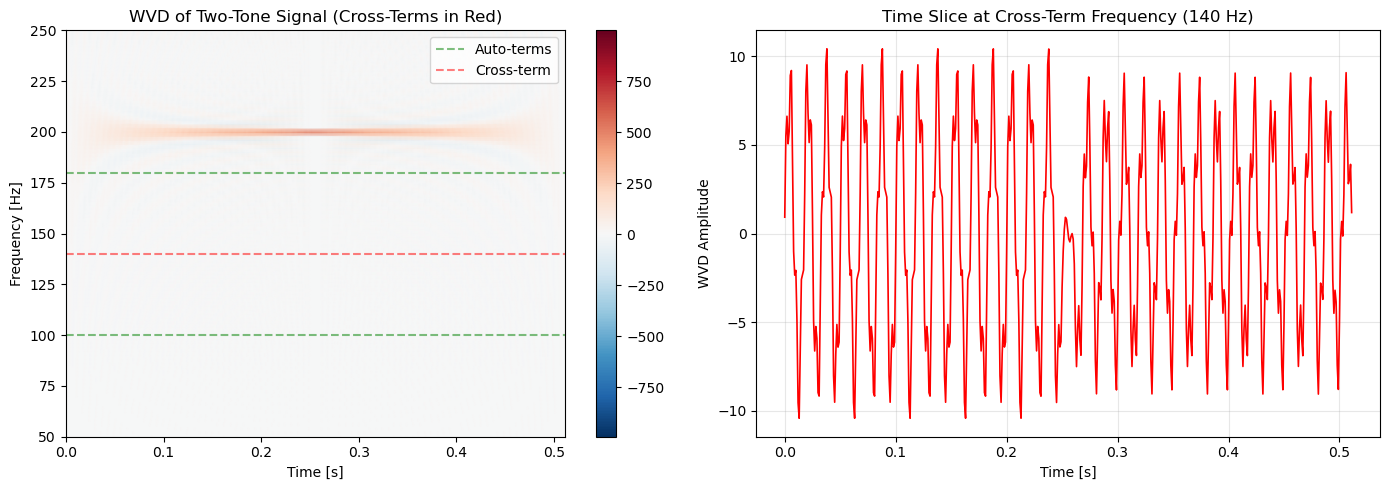

In [24]:
fs = 1000
N = 512
t = np.arange(N) / fs
f1, f2 = 100, 180
two_tone = np.sin(2 * np.pi * f1 * t) + np.sin(2 * np.pi * f2 * t)
two_tone_a = hilbert(two_tone)

t_wvd, f_wvd, W = wigner_ville(two_tone_a, fs, max_lag=250)
pos_mask = f_wvd >= 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Auto-terms and cross-terms visible
im1 = axes[0].pcolormesh(t_wvd, f_wvd[pos_mask], W[:, pos_mask].T,
                          shading='gouraud', cmap='RdBu_r')
axes[0].axhline(f1, color='g', linestyle='--', alpha=0.5, label='Auto-terms')
axes[0].axhline(f2, color='g', linestyle='--', alpha=0.5)
axes[0].axhline((f1+f2)/2, color='r', linestyle='--', alpha=0.5, label='Cross-term')
axes[0].set_title('WVD of Two-Tone Signal (Cross-Terms in Red)')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Frequency [Hz]')
axes[0].set_ylim(50, 250)
axes[0].legend()
fig.colorbar(im1, ax=axes[0])

# Time slice at the cross-term frequency
idx_cross = np.argmin(np.abs(f_wvd[pos_mask] - (f1+f2)/2))
freqs_pos = f_wvd[pos_mask]
W_pos = W[:, pos_mask]
axes[1].plot(t_wvd, W_pos[:, idx_cross], 'r-', linewidth=1.2)
axes[1].set_title('Time Slice at Cross-Term Frequency ({:.0f} Hz)'.format(freqs_pos[idx_cross]))
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('WVD Amplitude')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Cross Wigner–Ville Distribution

The cross-WVD between two different signals $x$ and $y$ is:

$$W_{xy}(t, f) = \int x\left(t + \frac{\tau}{2}\right) y^*\left(t - \frac{\tau}{2}\right) e^{-j 2\pi f \tau} d\tau$$

It is complex-valued and measures the time-frequency correlation between signals. Large magnitude indicates shared time-frequency structure; the phase encodes relative timing.


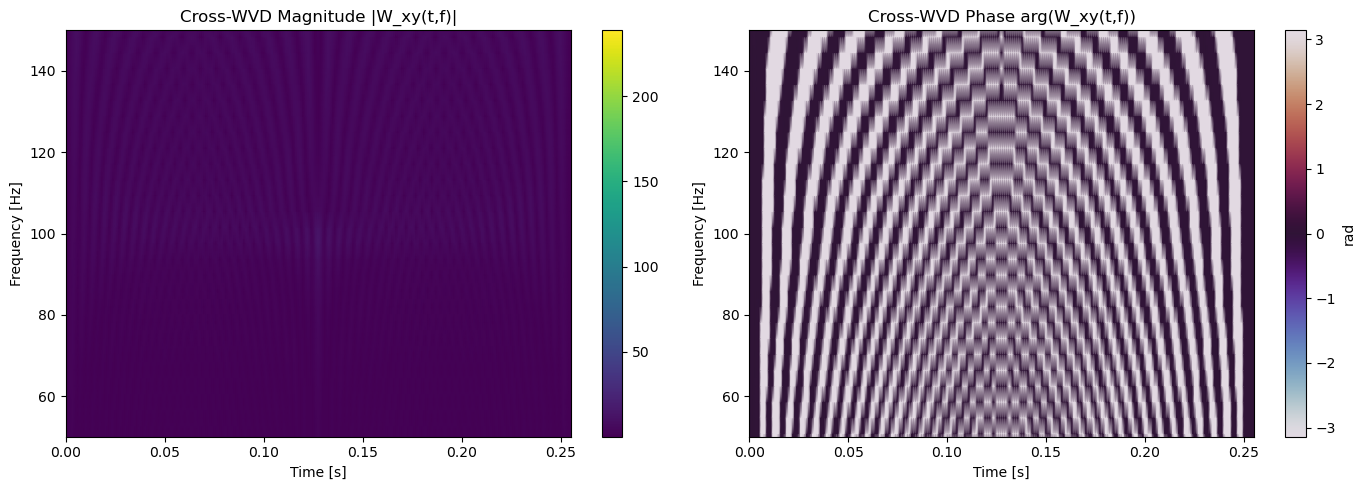

In [25]:
def cross_wigner_ville(x, y, fs, max_lag=None):
    """Cross-Wigner-Ville distribution between two signals."""
    x = np.asarray(x, dtype=complex)
    y = np.asarray(y, dtype=complex)
    N = len(x)
    if len(y) != N:
        raise ValueError("Signals must have equal length")
    
    if max_lag is None:
        max_lag = N // 2
    max_lag = min(max_lag, N // 2)
    
    n_lags = 2 * max_lag
    K = np.zeros((N, n_lags), dtype=complex)
    
    for m in range(max_lag):
        valid = N - 2 * m
        if valid > 0:
            idx = max_lag + m
            K[m : m + valid, idx] = x[2*m : 2*m + valid] * np.conj(y[0 : valid])
    
    for m in range(1, max_lag + 1):
        valid = N - 2 * m
        if valid > 0:
            idx = max_lag - m
            K[m : m + valid, idx] = x[0 : valid] * np.conj(y[2*m : 2*m + valid])
    
    K_shifted = np.fft.ifftshift(K, axes=1)
    W = np.fft.fft(K_shifted, axis=1)
    W = np.fft.fftshift(W, axes=1)
    
    freqs = np.fft.fftshift(np.fft.fftfreq(n_lags, 1/fs))
    t = np.arange(N) / fs
    return t, freqs, W


fs = 1000
N = 256
t = np.arange(N) / fs
x = hilbert(np.sin(2 * np.pi * 100 * t))
y = hilbert(np.sin(2 * np.pi * 100 * (t - 0.02)))  # Delayed version

t_cwvd, f_cwvd, W_cross = cross_wigner_ville(x, y, fs, max_lag=200)
pos_mask = f_cwvd >= 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im1 = axes[0].pcolormesh(t_cwvd, f_cwvd[pos_mask], np.abs(W_cross[:, pos_mask]).T,
                          shading='gouraud', cmap='viridis')
axes[0].set_title('Cross-WVD Magnitude |W_xy(t,f)|')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Frequency [Hz]')
axes[0].set_ylim(50, 150)
fig.colorbar(im1, ax=axes[0])

im2 = axes[1].pcolormesh(t_cwvd, f_cwvd[pos_mask], np.angle(W_cross[:, pos_mask]).T,
                          shading='gouraud', cmap='twilight')
axes[1].set_title('Cross-WVD Phase arg(W_xy(t,f))')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Frequency [Hz]')
axes[1].set_ylim(50, 150)
fig.colorbar(im2, ax=axes[1], label='rad')

plt.tight_layout()
plt.show()


## 6. Marginal Properties

The WVD satisfies the marginal properties exactly (in the continuous case):

$$\int_{-\infty}^{\infty} W(t, f) \, df = |x(t)|^2 \quad \text{(time marginal)}$$

$$\int_{-\infty}^{\infty} W(t, f) \, dt = |X(f)|^2 \quad \text{(frequency marginal)}$$

In the discrete implementation, these hold approximately with proper normalization. The time marginal gives the instantaneous power; the frequency marginal gives the spectral power density.


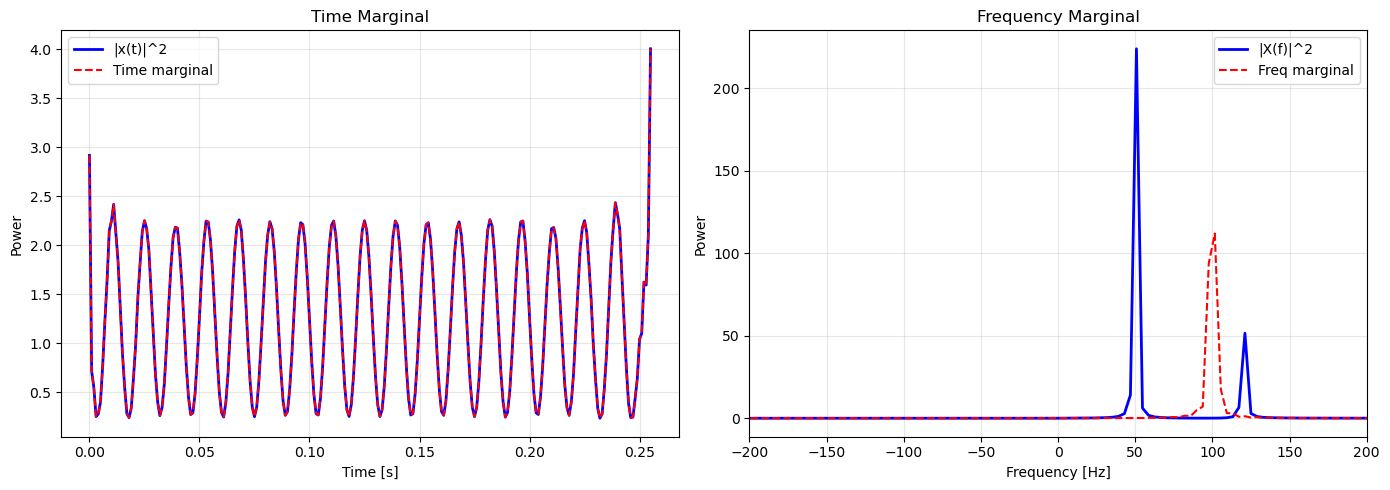

Mean squared error (time marginal):  0.0000
Mean squared error (freq marginal):  296.2441


In [26]:
fs = 1000
N = 256
t = np.arange(N) / fs
signal = np.sin(2 * np.pi * 50 * t) + 0.5 * np.cos(2 * np.pi * 120 * t)
signal_a = hilbert(signal)

t_wvd, f_wvd, W = wigner_ville(signal_a, fs, max_lag=200)

# Normalize for discrete marginals
time_marginal = np.sum(W, axis=1) / W.shape[1]
freq_marginal = np.sum(W, axis=0) / W.shape[0]

# Reference quantities
inst_power = np.abs(signal_a)**2
spectrum = np.fft.fftshift(np.fft.fft(signal_a))
spec_power = np.abs(spectrum)**2 / N
spec_freqs = np.fft.fftshift(np.fft.fftfreq(N, 1/fs))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(t, inst_power, 'b-', linewidth=2, label='|x(t)|^2')
axes[0].plot(t, time_marginal, 'r--', linewidth=1.5, label='Time marginal')
axes[0].set_title('Time Marginal')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Power')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(spec_freqs, spec_power, 'b-', linewidth=2, label='|X(f)|^2')
axes[1].plot(f_wvd, freq_marginal, 'r--', linewidth=1.5, label='Freq marginal')
axes[1].set_title('Frequency Marginal')
axes[1].set_xlabel('Frequency [Hz]')
axes[1].set_ylabel('Power')
axes[1].set_xlim(-200, 200)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Mean squared error (time marginal):  {:.4f}".format(np.mean((inst_power - time_marginal)**2)))
print("Mean squared error (freq marginal):  {:.4f}".format(np.mean((spec_power - freq_marginal)**2)))


## 7. Smoothed Pseudo-Wigner–Ville (SPWVD)

Cross-terms oscillate rapidly and can be attenuated by **smoothing** the WVD. The Smoothed Pseudo-WVD applies:

- A **lag window**: limits the lag length (frequency smoothing), reducing side lobes
- A **time smoothing filter**: convolves along the time axis, suppressing oscillating cross-terms

The trade-off is reduced time-frequency resolution. The SPWVD is a bridge between the high-resolution WVD and the cross-term-free STFT.


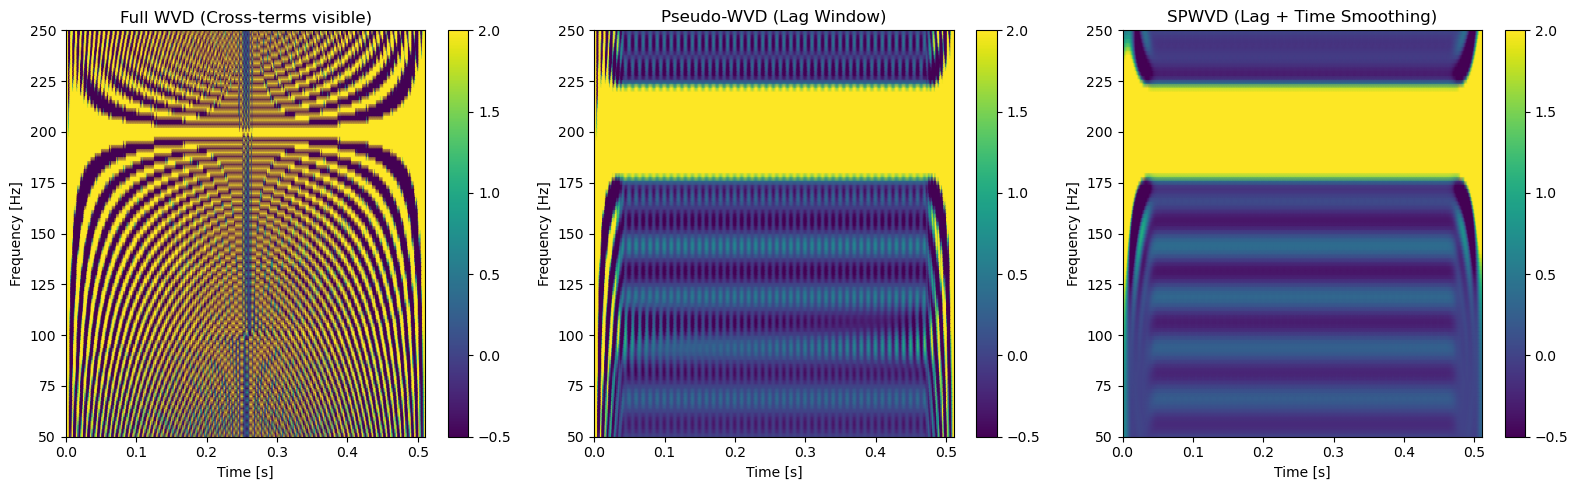

In [28]:
fs = 1000
N = 512
t = np.arange(N) / fs
f1, f2 = 100, 200
signal_sp = np.sin(2 * np.pi * f1 * t) + np.sin(2 * np.pi * f2 * t)
signal_sp_a = hilbert(signal_sp)

# Full WVD
t1, f1_arr, W_full = wigner_ville(signal_sp_a, fs, max_lag=250)
# Pseudo-WVD (lag window only)
lag_win = np.hamming(80)
t2, f2_arr, W_pseudo = wigner_ville(signal_sp_a, fs, max_lag=250, lag_window=lag_win)
# SPWVD (lag window + time smoothing)
t3, f3_arr, W_smooth = wigner_ville(signal_sp_a, fs, max_lag=250, 
                                     lag_window=lag_win, time_sigma=5.0)

pos1 = f1_arr >= 0
pos2 = f2_arr >= 0
pos3 = f3_arr >= 0

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

im1 = axes[0].pcolormesh(t1, f1_arr[pos1], W_full[:, pos1].T,
                          shading='gouraud', cmap='viridis', vmin=-0.5, vmax=2.0)
axes[0].set_title('Full WVD (Cross-terms visible)')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Frequency [Hz]')
axes[0].set_ylim(50, 250)
fig.colorbar(im1, ax=axes[0])

im2 = axes[1].pcolormesh(t2, f2_arr[pos2], W_pseudo[:, pos2].T,
                          shading='gouraud', cmap='viridis', vmin=-0.5, vmax=2.0)
axes[1].set_title('Pseudo-WVD (Lag Window)')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Frequency [Hz]')
axes[1].set_ylim(50, 250)
fig.colorbar(im2, ax=axes[1])

im3 = axes[2].pcolormesh(t3, f3_arr[pos3], W_smooth[:, pos3].T,
                          shading='gouraud', cmap='viridis', vmin=-0.5, vmax=2.0)
axes[2].set_title('SPWVD (Lag + Time Smoothing)')
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('Frequency [Hz]')
axes[2].set_ylim(50, 250)
fig.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()


## Summary

| Property | Description |
|----------|-------------|
| **Definition** | Fourier transform of the instantaneous autocorrelation |
| **Resolution** | Perfect for single components (no uncertainty trade-off) |
| **Real-valued** | Always real, but can be negative |
| **Marginals** | Satisfies time and frequency energy marginals exactly |
| **Quadratic** | Cross-terms appear between multiple components |
| **Analytic signal** | Required to avoid positive/negative frequency interference |
| **Pseudo-WVD** | Lag window limits frequency smearing |
| **SPWVD** | Time + frequency smoothing suppresses cross-terms |
| **Cross-WVD** | Complex measure of time-frequency correlation |

The WVD offers the finest time-frequency resolution of any quadratic representation, but its cross-terms make it challenging for multi-component signals. Smoothing variants trade resolution for interpretability.
